# 🤖 Notebook 02 — ML Modelling & Explainability
**XGBoost + Optuna HPO → Classification + Regression → SHAP**

All model logic lives in `src/billionaires/models/`.


In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

from billionaires.data     import load_raw, validate_schema, clean
from billionaires.features import build_features, get_clf_features, get_reg_features
from billionaires.models   import SelfMadeClassifier, WorthRegressor
from billionaires.viz      import confusion_matrix_plot, actual_vs_predicted, shap_summary

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH   = Path("../data/raw/Billionaires Statistics Dataset.csv")
SEED = 42
print("✅ Ready")


✅ Ready


## 1. Load & Prepare

In [2]:
df = build_features(clean(load_raw(DATA_PATH)))
print(f"Shape: {df.shape}")


Shape: (2640, 43)


## 2. Classification — Predict Self-Made (XGBoost + Optuna)

In [3]:
clf_feats = get_clf_features()
# Keep only features that actually exist after engineering
clf_feats = [f for f in clf_feats if f in df.columns]

clf_df = df[clf_feats + ["selfMade"]].dropna()
X_clf  = clf_df[clf_feats].values
y_clf  = clf_df["selfMade"].values

# ── 70 / 15 / 15 split (train / val / test) ──────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_clf, y_clf, test_size=0.30, random_state=SEED, stratify=y_clf
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)
print(f"Train {X_tr.shape}  |  Val {X_val.shape}  |  Test {X_te.shape}")
print(f"Class balance — 0:{(y_tr==0).sum()}  1:{(y_tr==1).sum()}")

Train (1848, 7)  |  Val (396, 7)  |  Test (396, 7)
Class balance — 0:580  1:1268


In [4]:
# ── Tune + fit ────────────────────────────────────────────────────────────
clf = SelfMadeClassifier(n_trials=40, seed=SEED)
clf.tune(X_tr, y_tr)
clf.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

  0%|          | 0/40 [00:00<?, ?it/s]

SelfMadeClassifier(n_trials=40, cv_folds=5, seed=42)

In [5]:
metrics = clf.evaluate(X_te, y_te)
print(f"ROC-AUC : {metrics['roc_auc']:.4f}")
print()
print(metrics["classification_report"])


ROC-AUC : 0.8436

              precision    recall  f1-score   support

   Inherited       0.81      0.52      0.63       124
   Self-Made       0.81      0.94      0.87       272

    accuracy                           0.81       396
   macro avg       0.81      0.73      0.75       396
weighted avg       0.81      0.81      0.80       396



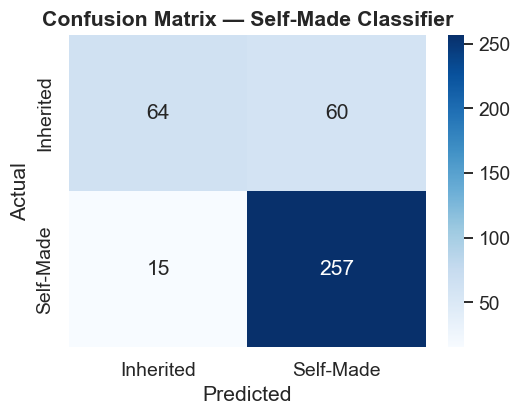

In [6]:
fig = confusion_matrix_plot(
    y_te, clf.predict(X_te),
    save_path=FIGURES_DIR / "05_confusion.png"
)
plt.show()


## 3. Regression — Predict log(Net Worth) (XGBoost + Optuna)

In [7]:
reg_feats = get_reg_features()
reg_feats = [f for f in reg_feats if f in df.columns]

reg_df = df[reg_feats + ["log_worth"]].dropna()
X_reg  = reg_df[reg_feats].values
y_reg  = reg_df["log_worth"].values

# ── 70 / 15 / 15 split (train / val / test) ──────────────────────────
X_tr_r, X_tmp_r, y_tr_r, y_tmp_r = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=SEED
)
X_val_r, X_te_r, y_val_r, y_te_r = train_test_split(
    X_tmp_r, y_tmp_r, test_size=0.50, random_state=SEED
)
print(f"Train {X_tr_r.shape}  |  Val {X_val_r.shape}  |  Test {X_te_r.shape}")

Train (1848, 6)  |  Val (396, 6)  |  Test (396, 6)


In [8]:
reg = WorthRegressor(n_trials=40, seed=SEED)
reg.tune(X_tr_r, y_tr_r)
reg.fit(X_tr_r, y_tr_r, X_val=X_val_r, y_val=y_val_r)

  0%|          | 0/40 [00:00<?, ?it/s]

WorthRegressor(n_trials=40, cv_folds=5, seed=42)

In [9]:
m = reg.evaluate(X_te_r, y_te_r)
print(f"MAE : {m['mae']:.4f}")
print(f"RMSE: {m['rmse']:.4f}")
print(f"R²  : {m['r2']:.4f}")


MAE : 0.5839
RMSE: 0.7230
R²  : 0.0821


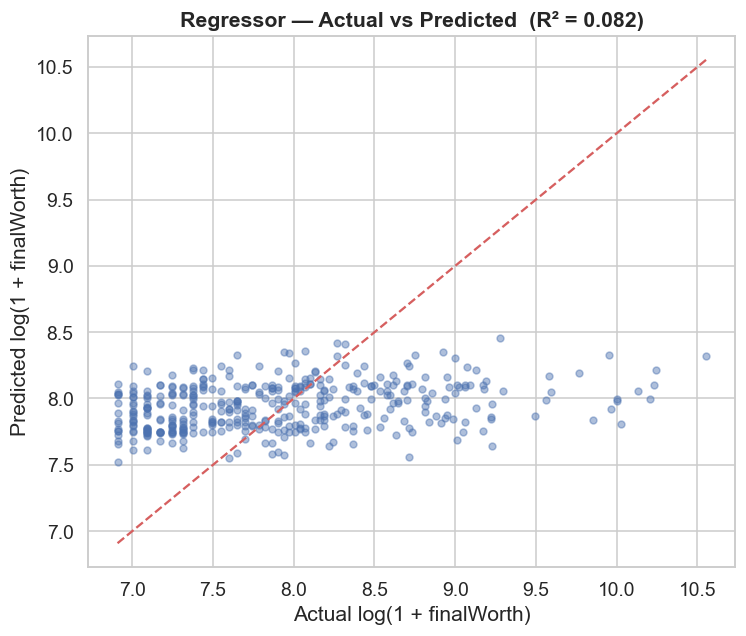

In [10]:
fig = actual_vs_predicted(
    y_te_r, reg.predict(X_te_r), r2=m["r2"],
    save_path=FIGURES_DIR / "06_actual_vs_pred.png"
)
plt.show()


## 4. SHAP Explainability

SHAP — Classifier (Self-Made prediction)


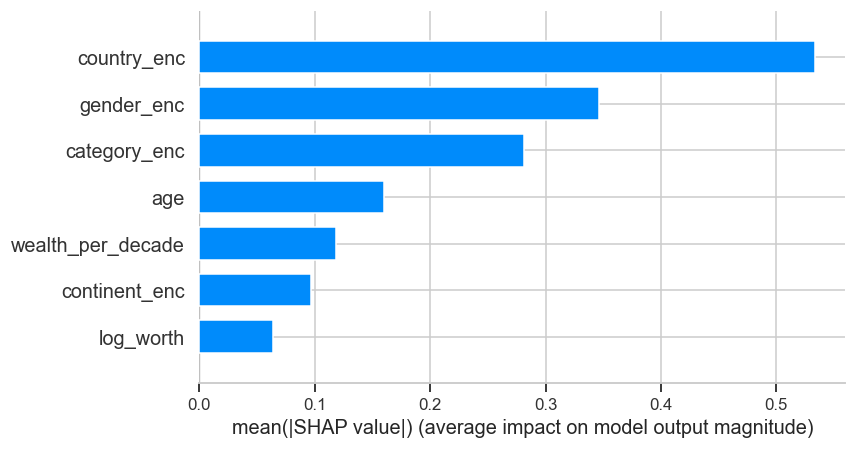

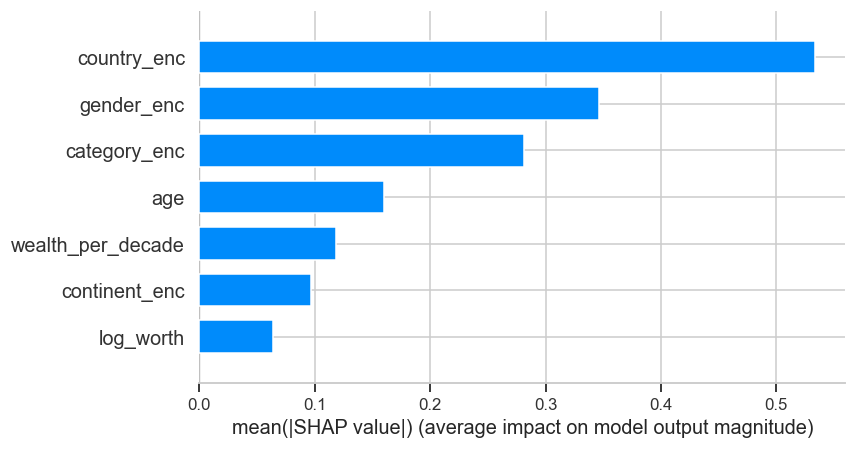

In [11]:
print("SHAP — Classifier (Self-Made prediction)")
shap_summary(clf.model_, X_te, clf_feats,
             plot_type="bar",
             save_path=FIGURES_DIR / "07_shap_clf_bar.png")


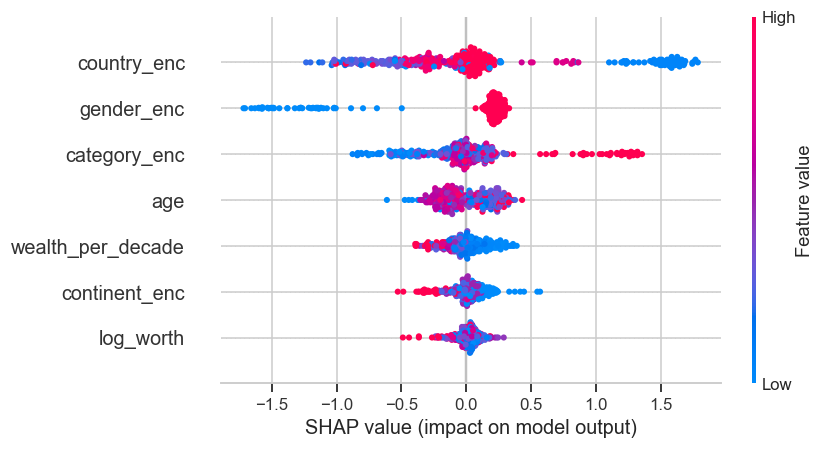

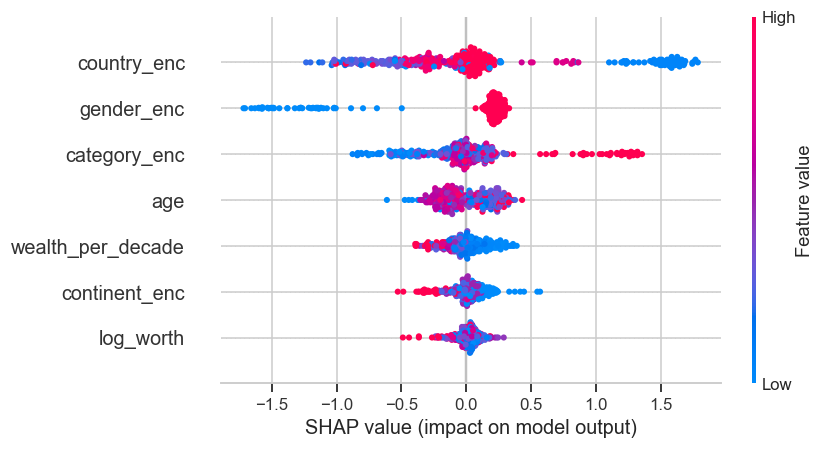

In [12]:
shap_summary(clf.model_, X_te, clf_feats,
             plot_type="dot",
             save_path=FIGURES_DIR / "07_shap_clf_dot.png")


SHAP — Regressor (Net Worth prediction)


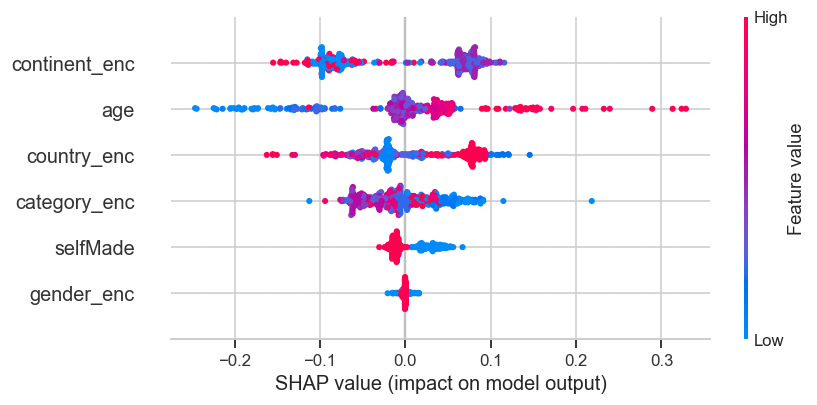

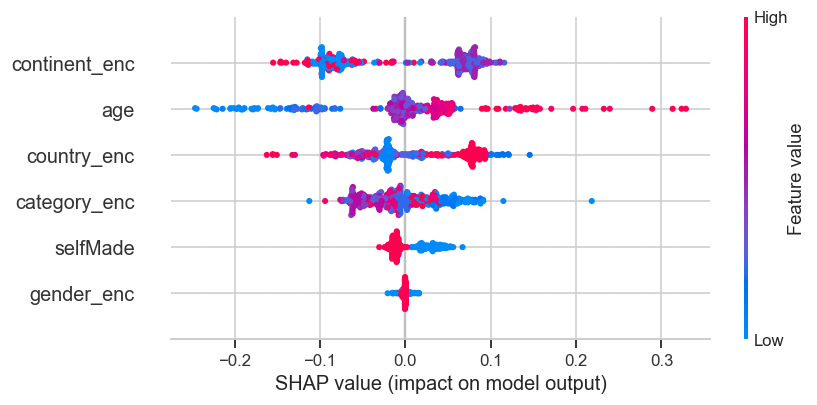

In [13]:
print("SHAP — Regressor (Net Worth prediction)")
shap_summary(reg.model_, X_te_r, reg_feats,
             plot_type="dot",
             save_path=FIGURES_DIR / "08_shap_reg_dot.png")


## 5. Clustering — K-Means + PCA

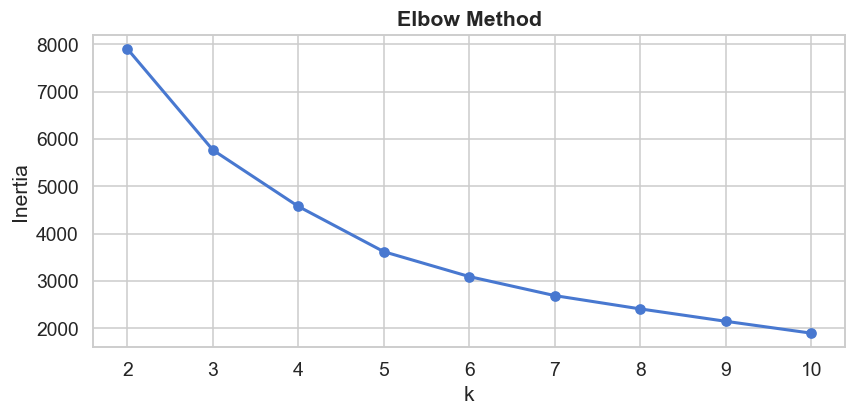

In [14]:
cluster_cols = ["log_worth", "age", "selfMade", "wealth_per_decade"]
cluster_df = df[cluster_cols].dropna().copy()
X_c = StandardScaler().fit_transform(cluster_df)

# Elbow
inertias = [KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_c).inertia_
            for k in range(2, 11)]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 11), inertias, "bo-", lw=2)
ax.set_xlabel("k"); ax.set_ylabel("Inertia")
ax.set_title("Elbow Method")
plt.tight_layout(); plt.show()


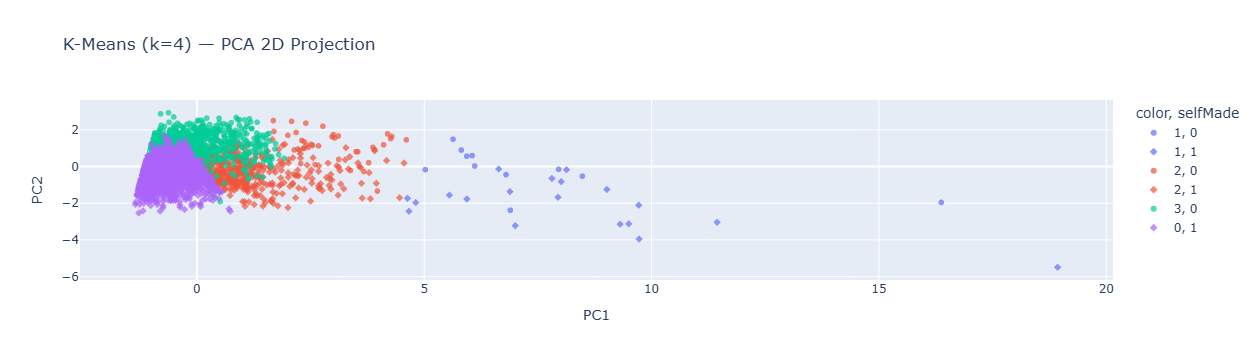


Cluster profiles:
         log_worth    age  selfMade  wealth_per_decade
cluster                                               
0             7.52  62.78      1.00             337.64
1            11.13  63.60      0.63           12177.10
2             8.96  70.70      0.92            1431.84
3             7.86  65.78      0.00             498.49


In [15]:
OPTIMAL_K = 4   # adjust after inspecting elbow

km = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
cluster_df["cluster"] = km.fit_predict(X_c)

pcs = PCA(n_components=2, random_state=SEED).fit_transform(X_c)
cluster_df["PC1"] = pcs[:, 0]
cluster_df["PC2"] = pcs[:, 1]

fig = px.scatter(cluster_df, x="PC1", y="PC2",
                 color=cluster_df["cluster"].astype(str),
                 symbol="selfMade",
                 hover_data=["log_worth", "age"],
                 title=f"K-Means (k={OPTIMAL_K}) — PCA 2D Projection")
fig.update_traces(marker_size=6, opacity=0.7)
fig.show()

print("\nCluster profiles:")
print(cluster_df.groupby("cluster")[cluster_cols].mean().round(2))
